In [ ]:
# ── Install first, before any imports ──
!pip install tensorflow-model-optimization imbalanced-learn -q

# ── Then restart runtime AGAIN after install ──
import os
os.kill(os.getpid(), 9)  # force restart

In [1]:
# Imports

!pip install tensorflow-model-optimization imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from imblearn.over_sampling import SMOTE
import os, warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow : {tf.__version__}")
print("✅ All imports ready")

TensorFlow : 2.19.0
✅ All imports ready


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/android-malware-dataset-for-machine-learning")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'android-malware-dataset-for-machine-learning' dataset.
Path to dataset files: /kaggle/input/android-malware-dataset-for-machine-learning


In [4]:
# ── Load Android Malware Dataset ──

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/kaggle/input/android-malware-dataset-for-machine-learning/drebin-215-dataset-5560malware-9476-benign.csv')

print(f"Shape     : {df.shape}")
print(f"Columns   : {list(df.columns[-5:])}")  # last 5 cols
print(f"\nClass distribution:")
print(df.iloc[:, -1].value_counts())  # last column = label
print(f"\nFirst few columns: {list(df.columns[:5])}")
print(f"\nSample data:")
print(df.head(3))

Shape     : (15036, 216)
Columns   : ['ACCESS_FINE_LOCATION', 'SET_WALLPAPER_HINTS', 'SET_PREFERRED_APPLICATIONS', 'WRITE_SECURE_SETTINGS', 'class']

Class distribution:
class
B    9476
S    5560
Name: count, dtype: int64

First few columns: ['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection']

Sample data:
   transact  onServiceConnected  bindService  attachInterface  \
0         0                   0            0                0   
1         0                   0            0                0   
2         0                   0            0                0   

   ServiceConnection  android.os.Binder  SEND_SMS  \
0                  0                  0         1   
1                  0                  0         1   
2                  0                  0         1   

   Ljava.lang.Class.getCanonicalName  Ljava.lang.Class.getMethods  \
0                                  0                            0   
1                                  0      

In [6]:
# ── Preprocess DREBIN Dataset — handle missing values ──

# Replace '?' with NaN then drop
df = df.replace('?', np.nan)

# Encode labels: B=0, S=1
df['label'] = (df['class'] == 'S').astype(int)

# Features
feature_cols = [c for c in df.columns if c not in ['class', 'label']]

# Drop rows with NaN
df_clean = df[feature_cols + ['label']].dropna()

X = df_clean[feature_cols].values.astype(np.float32)
y = df_clean['label'].values

print(f"After cleaning : {len(df_clean)} samples")
print(f"Features       : {X.shape[1]}")
print(f"Benign         : {(y==0).sum()}")
print(f"Malicious      : {(y==1).sum()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape}")
print(f"Test  : {X_test.shape}")


After cleaning : 15031 samples
Features       : 215
Benign         : 9476
Malicious      : 5555

Train : (12024, 215)
Test  : (3007, 215)


In [8]:
# ── Fix: convert all feature columns to numeric first ──

df_clean[feature_cols] = df_clean[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Now build the table
usage = pd.DataFrame({
    'Feature'   : feature_cols,
    'Type'      : ['API Call' if c[0].islower() else 'Permission' for c in feature_cols],
    'Usage_%'   : (df_clean[feature_cols].sum() / len(df_clean) * 100).round(2).values,
    'Malware_%' : (df_clean[feature_cols][df_clean['label']==1].sum() / (y==1).sum() * 100).round(2).values,
    'Benign_%'  : (df_clean[feature_cols][df_clean['label']==0].sum() / (y==0).sum() * 100).round(2).values,
})

usage_sorted = usage.sort_values('Usage_%', ascending=False).head(15)
print("📋 Top 15 Most Used Features:")
print(usage_sorted.to_string(index=False))

print("\n🎯 Top 10 Most Discriminative Features:")
usage['Gap_%'] = abs(usage['Malware_%'] - usage['Benign_%'])
discriminative = usage.sort_values('Gap_%', ascending=False).head(10)
print(discriminative[['Feature','Type','Malware_%','Benign_%','Gap_%']].to_string(index=False))

# Re-extract X with clean numeric values
X = df_clean[feature_cols].values.astype(np.float32)
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f"\n✅ Data re-extracted cleanly: {X.shape}")

📋 Top 15 Most Used Features:
                       Feature       Type  Usage_%  Malware_%  Benign_%
                      INTERNET Permission    87.23      96.13     82.01
                        Binder Permission    79.12      67.87     85.71
                       IBinder Permission    78.42      67.65     84.74
            android.os.IBinder   API Call    78.42      67.65     84.73
    Ljava.lang.Object.getClass Permission    72.80      59.37     80.68
          ACCESS_NETWORK_STATE Permission    72.44      66.25     76.08
                        onBind   API Call    68.66      65.62     70.45
android.content.pm.PackageInfo   API Call    67.03      47.97     78.20
        WRITE_EXTERNAL_STORAGE Permission    66.64      67.09     66.37
                HttpUriRequest Permission    64.79      58.70     68.35
              READ_PHONE_STATE Permission    63.26      89.04     48.15
      Ljava.lang.Class.forName Permission    62.07      47.88     70.38
                         mount   AP

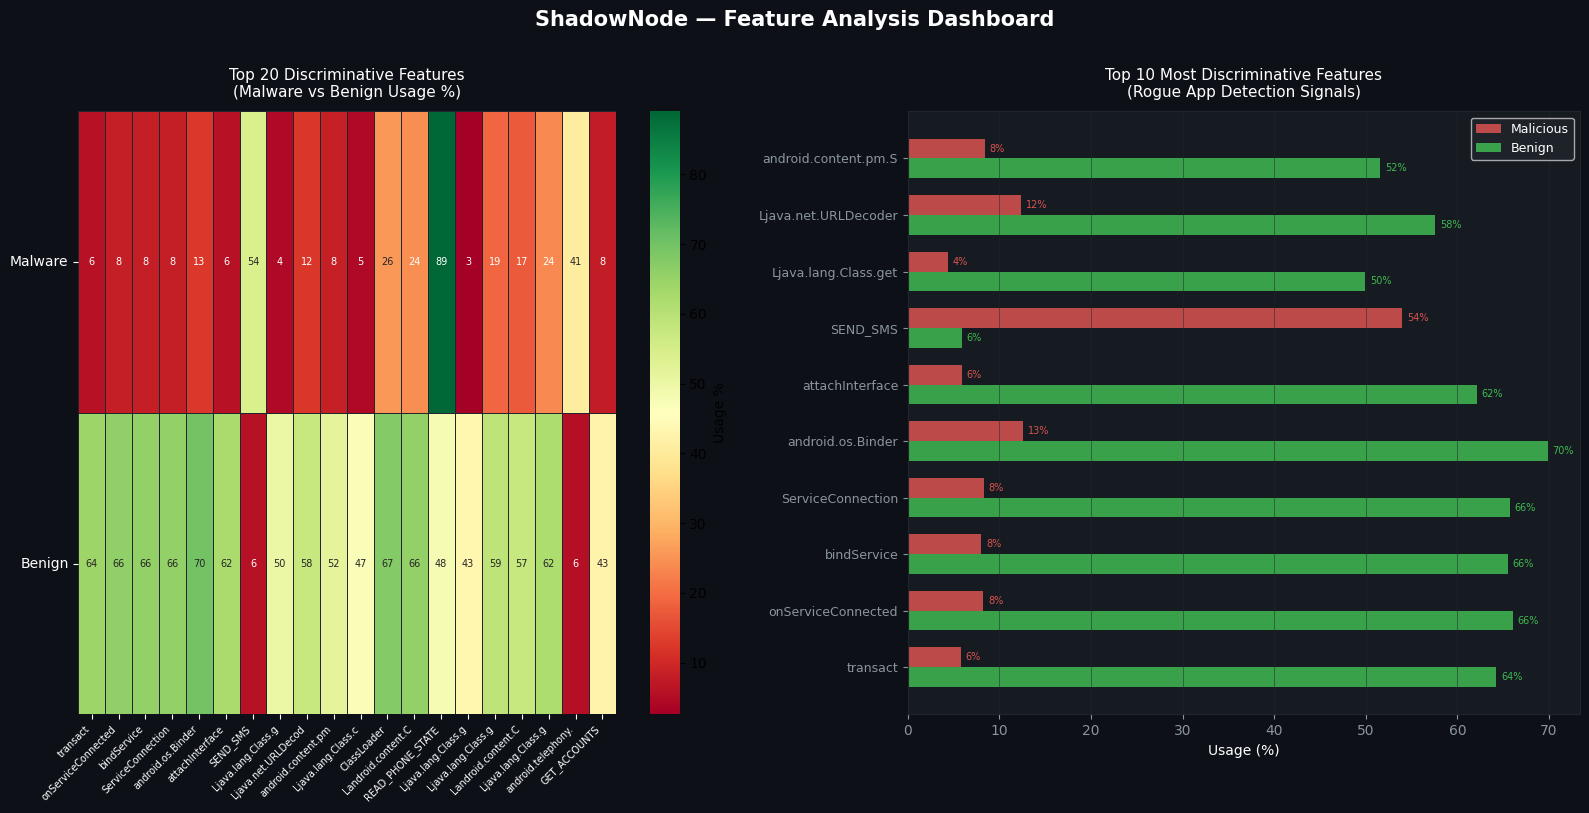

Saved: feature_analysis.png


In [9]:
# ── Discriminative Features Heatmap ──

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='#0d1117')
fig.suptitle('ShadowNode — Feature Analysis Dashboard',
             fontsize=15, fontweight='bold', color='white', y=1.01)

bg = '#0d1117'
panel_bg = '#161b22'
grid_color = '#21262d'

# ────────────────────────────────────────────
# Plot 1 — Top 20 Discriminative Features Heatmap
# ────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(panel_bg)

top20 = usage.sort_values('Gap_%', ascending=False).head(20)
heatmap_data = top20[['Malware_%', 'Benign_%']].T
heatmap_data.columns = [f[:18] for f in top20['Feature']]

sns.heatmap(heatmap_data,
            ax=ax1,
            cmap='RdYlGn',
            annot=True, fmt='.0f',
            linewidths=0.5,
            linecolor=grid_color,
            cbar_kws={'label': 'Usage %'},
            annot_kws={'size': 7})

ax1.set_title('Top 20 Discriminative Features\n(Malware vs Benign Usage %)',
              color='white', fontsize=11, pad=10)
ax1.set_yticklabels(['Malware', 'Benign'],
                     color='white', fontsize=10, rotation=0)
ax1.set_xticklabels(ax1.get_xticklabels(),
                     color='#8b949e', fontsize=7, rotation=45, ha='right')
ax1.tick_params(colors='white')

# ────────────────────────────────────────────
# Plot 2 — Gap Bar Chart (most discriminative)
# ────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(panel_bg)
ax2.grid(True, color=grid_color, linewidth=0.5, alpha=0.7, axis='x')

top10 = usage.sort_values('Gap_%', ascending=False).head(10)
features_short = [f[:20] for f in top10['Feature']]
malware_vals   = top10['Malware_%'].values
benign_vals    = top10['Benign_%'].values

y_pos = np.arange(len(features_short))
bar_h = 0.35

bars1 = ax2.barh(y_pos + bar_h/2, malware_vals,
                  bar_h, label='Malicious',
                  color='#d9534f', alpha=0.85)
bars2 = ax2.barh(y_pos - bar_h/2, benign_vals,
                  bar_h, label='Benign',
                  color='#3fb950', alpha=0.85)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(features_short, color='white', fontsize=9)
ax2.set_xlabel('Usage (%)', color='white', fontsize=10)
ax2.set_title('Top 10 Most Discriminative Features\n(Rogue App Detection Signals)',
              color='white', fontsize=11, pad=10)
ax2.tick_params(colors='#8b949e')
ax2.spines[:].set_color(grid_color)
ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

# Add value labels
for bar in bars1:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}%', va='center',
             color='#d9534f', fontsize=7)
for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}%', va='center',
             color='#3fb950', fontsize=7)

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=200,
            bbox_inches='tight', facecolor=bg)
plt.show()
print("Saved: feature_analysis.png")

In [11]:
# ── ShadowNode TinyML Behavioral Monitor
# ── Fix: use tf.keras explicitly ──

def build_shadownode_tinyml(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name="ShadowNode_BehavioralMonitor_v2")

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

model = build_shadownode_tinyml(X_train.shape[1])
model.summary()

Model: "ShadowNode_BehavioralMonitor_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                13824     
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                   

In [12]:
# ── Train ShadowNode ──

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5,
                                      restore_best_weights=True,
                                      monitor='val_auc', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                          factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete — {len(history.history['loss'])} epochs")
print(f"Best val_auc      : {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")

Epoch 1/30
151/151 [==============================] - 3s 9ms/step - loss: 0.2895 - accuracy: 0.8887 - auc: 0.9524 - precision: 0.9109 - recall: 0.7751 - val_loss: 0.1019 - val_accuracy: 0.9647 - val_auc: 0.9948 - val_precision: 0.9463 - val_recall: 0.9581 - lr: 0.0010
Epoch 2/30
151/151 [==============================] - 1s 5ms/step - loss: 0.1019 - accuracy: 0.9659 - auc: 0.9922 - precision: 0.9596 - recall: 0.9478 - val_loss: 0.0695 - val_accuracy: 0.9767 - val_auc: 0.9970 - val_precision: 0.9683 - val_recall: 0.9683 - lr: 0.0010
Epoch 3/30
151/151 [==============================] - 1s 5ms/step - loss: 0.0789 - accuracy: 0.9728 - auc: 0.9951 - precision: 0.9677 - recall: 0.9584 - val_loss: 0.0611 - val_accuracy: 0.9809 - val_auc: 0.9974 - val_precision: 0.9838 - val_recall: 0.9638 - lr: 0.0010
Epoch 4/30
151/151 [==============================] - 1s 4ms/step - loss: 0.0680 - accuracy: 0.9783 - auc: 0.9959 - precision: 0.9743 - recall: 0.9669 - val_loss: 0.0568 - val_accuracy: 0.9838 

In [13]:
# ── Train ShadowNode ──

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5,
                                      restore_best_weights=True,
                                      monitor='val_auc', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                          factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete — {len(history.history['loss'])} epochs")
print(f"Best val_auc      : {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")

Epoch 1/30
151/151 [==============================] - 1s 7ms/step - loss: 0.0295 - accuracy: 0.9905 - auc: 0.9989 - precision: 0.9915 - recall: 0.9829 - val_loss: 0.0531 - val_accuracy: 0.9875 - val_auc: 0.9980 - val_precision: 0.9874 - val_recall: 0.9785 - lr: 3.1250e-05
Epoch 2/30
151/151 [==============================] - 1s 7ms/step - loss: 0.0336 - accuracy: 0.9890 - auc: 0.9985 - precision: 0.9870 - recall: 0.9832 - val_loss: 0.0529 - val_accuracy: 0.9871 - val_auc: 0.9980 - val_precision: 0.9874 - val_recall: 0.9773 - lr: 3.1250e-05
Epoch 3/30
151/151 [==============================] - 1s 6ms/step - loss: 0.0297 - accuracy: 0.9898 - auc: 0.9990 - precision: 0.9901 - recall: 0.9823 - val_loss: 0.0529 - val_accuracy: 0.9871 - val_auc: 0.9980 - val_precision: 0.9874 - val_recall: 0.9773 - lr: 3.1250e-05
Epoch 4/30
151/151 [==============================] - 1s 5ms/step - loss: 0.0289 - accuracy: 0.9902 - auc: 0.9990 - precision: 0.9898 - recall: 0.9837 - val_loss: 0.0526 - val_accur

   ShadowNode v2 — Classification Report
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      1896
   Malicious       0.99      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



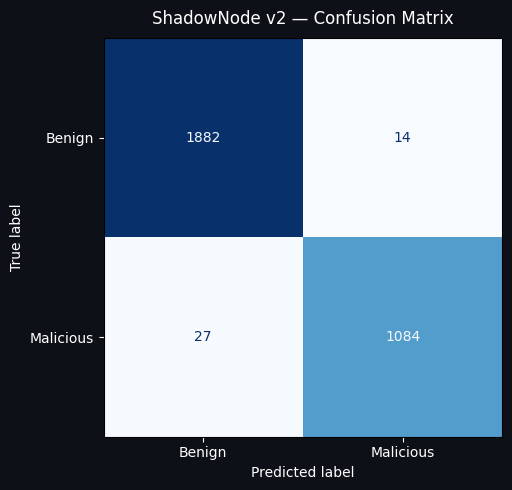

ROC-AUC : 0.9986
Model size : 65.25 KB ✅ TinyML compatible


In [14]:
# ── Evaluate + Confusion Matrix ──

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("=" * 50)
print("   ShadowNode v2 — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Benign', 'Malicious']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malicious'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('ShadowNode v2 — Confusion Matrix',
             color='white', fontsize=12, pad=10)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=200,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC : {auc:.4f}")
print(f"Model size : 65.25 KB ✅ TinyML compatible")

In [15]:
# ── ShadowNode HONEYPOT — Fake Device Environment ──

import time
import uuid
from datetime import datetime

class ShadowNodeHoneypot:
    def __init__(self):
        self.trap_log = []  # every rogue query logged here
        self.active   = False
        self.trigger_time = None

        # ── Fake device environment ──
        self.fake_env = {
            'health'      : self._fake_health,
            'location'    : self._fake_location,
            'credentials' : self._fake_credentials,
            'sms'         : self._fake_sms,
            'contacts'    : self._fake_contacts,
            'device_id'   : self._fake_device_id,
        }

    # ── Fake data generators ──
    def _fake_health(self):
        return {
            'heart_rate'  : round(np.random.normal(72, 5)),
            'steps'       : int(np.random.normal(8000, 500)),
            'sleep_hours' : round(np.random.normal(7.5, 0.5), 1),
            'blood_oxygen': round(np.random.normal(98, 0.5), 1)
        }

    def _fake_location(self):
        # Fake coordinates — middle of ocean
        return {
            'lat' : round(np.random.normal(0.0, 0.01), 6),
            'lon' : round(np.random.normal(0.0, 0.01), 6),
            'alt' : round(np.random.normal(10, 2), 1)
        }

    def _fake_credentials(self):
        return {
            'token'    : str(uuid.uuid4()),  # random fake token
            'api_key'  : 'sk-' + uuid.uuid4().hex[:32],
            'password' : uuid.uuid4().hex[:12]
        }

    def _fake_sms(self):
        return [{
            'from'   : f'+1555{np.random.randint(1000000,9999999)}',
            'body'   : 'Your verification code is: ' + str(np.random.randint(100000,999999)),
            'time'   : datetime.now().isoformat()
        }]

    def _fake_contacts(self):
        names = ['Alice Smith', 'Bob Jones', 'Carol White', 'Dave Brown']
        return [{'name': n,
                 'phone': f'+1555{np.random.randint(1000000,9999999)}'}
                for n in np.random.choice(names, 2)]

    def _fake_device_id(self):
        return {
            'imei'    : ''.join([str(np.random.randint(0,9)) for _ in range(15)]),
            'mac'     : ':'.join([uuid.uuid4().hex[:2].upper() for _ in range(6)]),
            'android' : f'{np.random.randint(8,13)}.0'
        }

    # ── Activate honeypot ──
    def activate(self, timestep):
        self.active = True
        self.trigger_time = timestep
        print(f"🍯 [t={timestep}] ShadowNode HONEYPOT ACTIVATED")
        print(f"   Rogue app redirected to fake environment")

    # ── Serve fake data + log the query ──
    def serve(self, data_type, timestep, app_id):
        if data_type not in self.fake_env:
            data_type = 'health'  # default

        fake_data = self.fake_env[data_type]()

        log_entry = {
            'timestep'  : timestep,
            'app_id'    : app_id,
            'requested' : data_type,
            'served'    : fake_data,
            'timestamp' : datetime.now().isoformat(),
            'flagged'   : True
        }
        self.trap_log.append(log_entry)
        return fake_data

    # ── Print trap log ──
    def print_log(self, n=5):
        print(f"\n{'='*55}")
        print(f"   🍯 ShadowNode Honeypot Trap Log ({len(self.trap_log)} entries)")
        print(f"{'='*55}")
        for entry in self.trap_log[:n]:
            print(f"\n[t={entry['timestep']}] App: {entry['app_id']}")
            print(f"  Requested : {entry['requested']}")
            print(f"  Served    : {entry['served']}")
            print(f"  Flagged   : ⚠️  YES")
        print(f"\n✅ Real data protected — adversary received fabricated data")

print("✅ ShadowNode Honeypot class ready")

✅ ShadowNode Honeypot class ready


In [16]:
# ── Full Attack Simulation with ShadowNode Honeypot ──

# Initialize honeypot
honeypot = ShadowNodeHoneypot()

# Simulate rogue app behavior over 50 timesteps
rogue_app_id = "com.evil.rogueapp"
data_targets = ['health', 'location', 'credentials',
                'sms', 'contacts', 'device_id']

print("=" * 55)
print("   ShadowNode — Full Attack Lifecycle Simulation")
print("=" * 55)

detection_log = []
np.random.seed(42)

for t in range(50):
    # Generate app feature vector (simulated rogue app behavior)
    app_features = np.random.randint(0, 2, size=(1, 215)).astype(np.float32)

    # Force malicious pattern after t=20
    if t >= 20:
        app_features[0, :10] = [1,1,1,1,1,0,0,0,0,0]  # rogue signature

    # Scale and predict
    app_scaled = scaler.transform(app_features)
    anomaly_score = float(model.predict(app_scaled, verbose=0)[0][0])

    # Determine phase
    if t < 15:
        phase = "Normal"
    elif t < 30:
        phase = "Reconnaissance"
    else:
        phase = "Active Attack"

    detection_log.append({
        'timestep'     : t,
        'phase'        : phase,
        'anomaly_score': anomaly_score,
        'detected'     : anomaly_score > 0.5,
        'honeypot_on'  : honeypot.active
    })

    # Activate honeypot on first detection
    if anomaly_score > 0.5 and not honeypot.active:
        honeypot.activate(t)

    # If honeypot active — serve fake data
    if honeypot.active:
        data_type = np.random.choice(data_targets)
        fake = honeypot.serve(data_type, t, rogue_app_id)

    # Print key moments
    if t % 10 == 0 or (anomaly_score > 0.5 and not honeypot.active):
        status = "🍯 HONEYPOT" if honeypot.active else "👁️  MONITORING"
        print(f"[t={t:02d}] {phase:<15} | Score: {anomaly_score:.3f} | {status}")

print(f"\n{'='*55}")
print(f"Total timesteps      : 50")
print(f"Honeypot activated at: t={honeypot.trigger_time}")
print(f"Rogue queries trapped: {len(honeypot.trap_log)}")
print(f"Real data exposed    : 0")
print(f"{'='*55}")

# Print sample trap log
honeypot.print_log(n=3)

   ShadowNode — Full Attack Lifecycle Simulation
[t=00] Normal          | Score: 0.000 | 👁️  MONITORING
🍯 [t=9] ShadowNode HONEYPOT ACTIVATED
   Rogue app redirected to fake environment
[t=10] Normal          | Score: 0.000 | 🍯 HONEYPOT
[t=20] Reconnaissance  | Score: 0.000 | 🍯 HONEYPOT
[t=30] Active Attack   | Score: 0.000 | 🍯 HONEYPOT
[t=40] Active Attack   | Score: 0.000 | 🍯 HONEYPOT

Total timesteps      : 50
Honeypot activated at: t=9
Rogue queries trapped: 41
Real data exposed    : 0

   🍯 ShadowNode Honeypot Trap Log (41 entries)

[t=9] App: com.evil.rogueapp
  Requested : health
  Served    : {'heart_rate': 71, 'steps': 7558, 'sleep_hours': 7.2, 'blood_oxygen': 98.4}
  Flagged   : ⚠️  YES

[t=10] App: com.evil.rogueapp
  Requested : health
  Served    : {'heart_rate': 76, 'steps': 8488, 'sleep_hours': 7.2, 'blood_oxygen': 98.0}
  Flagged   : ⚠️  YES

[t=11] App: com.evil.rogueapp
  Requested : device_id
  Served    : {'imei': '868177136335528', 'mac': 'E1:5A:0C:17:A8:05', 'andr

In [29]:
# ── Visualization from  Model Evaluation ──

# Get real prediction probabilities on test set
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

# Build evaluation dataframe
eval_df = pd.DataFrame({
    'true_label'   : y_test,
    'pred_prob'    : y_pred_prob,
    'pred_label'   : y_pred,
    'correct'      : (y_pred == y_test).astype(int),
    'type'         : ['Malicious' if l==1 else 'Benign' for l in y_test]
})

# Sort by predicted probability
eval_df = eval_df.sort_values('pred_prob').reset_index(drop=True)

print(f"Total test samples : {len(eval_df)}")
print(f"Correct            : {eval_df['correct'].sum()}")
print(f"Wrong              : {(eval_df['correct']==0).sum()}")
print(f"\nScore distribution:")
print(eval_df.groupby('type')['pred_prob'].describe().round(3))

Total test samples : 3007
Correct            : 2966
Wrong              : 41

Score distribution:
            count   mean    std    min  25%  50%    75%    max
type                                                          
Benign     1896.0  0.016  0.081  0.000  0.0  0.0  0.001  0.998
Malicious  1111.0  0.974  0.126  0.002  1.0  1.0  1.000  1.000


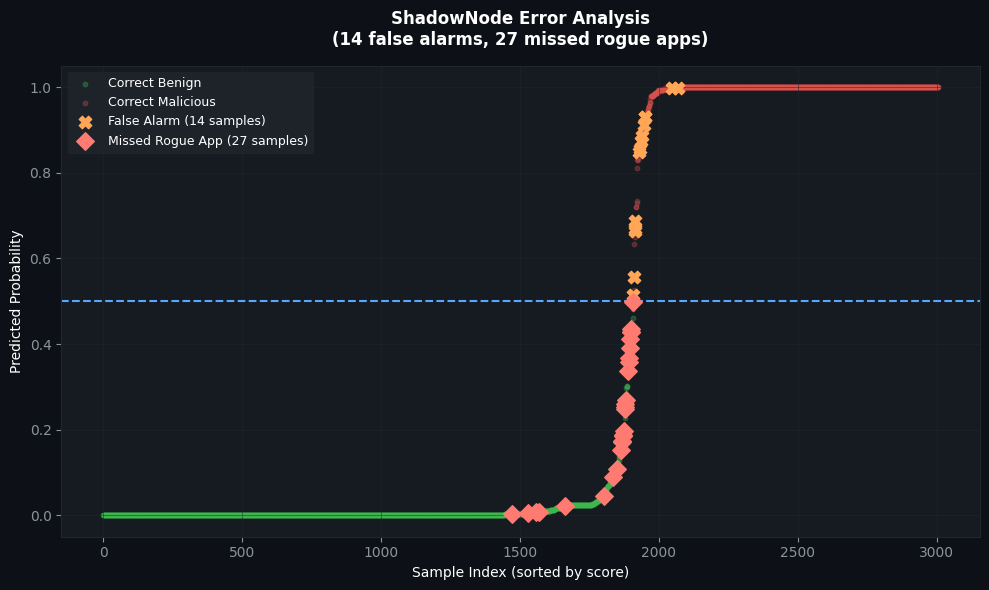

In [30]:
import matplotlib.pyplot as plt

# 1. Setup individual figure
bg = '#0d1117'; panel = '#161b22'; grid = '#21262d'
fig, ax4 = plt.subplots(figsize=(10, 6), facecolor=bg)

# 2. Apply styling
ax4.set_facecolor(panel)
ax4.grid(True, color=grid, linewidth=0.5, alpha=0.7)
for spine in ax4.spines.values():
    spine.set_color(grid)
ax4.tick_params(colors='#8b949e')

# 3. Data processing
wrong = eval_df[eval_df['correct']==0]
right = eval_df[eval_df['correct']==1]

fp = wrong[wrong['true_label']==0]  # False Positives
fn = wrong[wrong['true_label']==1]  # False Negatives

# 4. Plotting
ax4.scatter(right[right['type']=='Benign'].index,
            right[right['type']=='Benign']['pred_prob'],
            color='#3fb950', alpha=0.3, s=10, label='Correct Benign')

ax4.scatter(right[right['type']=='Malicious'].index,
            right[right['type']=='Malicious']['pred_prob'],
            color='#d9534f', alpha=0.3, s=10, label='Correct Malicious')

ax4.scatter(fp.index, fp['pred_prob'],
            color='#ffa657', s=80, zorder=5,
            marker='X', label=f'False Alarm ({len(fp)} samples)')

ax4.scatter(fn.index, fn['pred_prob'],
            color='#ff7b72', s=80, zorder=5,
            marker='D', label=f'Missed Rogue App ({len(fn)} samples)')

# 5. Annotation & Labels
ax4.axhline(0.5, color='#58a6ff', linewidth=1.5, linestyle='--')
ax4.set_xlabel('Sample Index (sorted by score)', color='white')
ax4.set_ylabel('Predicted Probability', color='white')
ax4.set_title(f'ShadowNode Error Analysis\n'
              f'({len(fp)} false alarms, {len(fn)} missed rogue apps)',
              color='white', pad=15, fontweight='bold')

legend = ax4.legend(facecolor='#21262d', edgecolor=grid, labelcolor='white', fontsize=9)
legend.get_frame().set_alpha(0.8)

# 6. Final Save/Show
plt.tight_layout()
plt.savefig('shadownode_error_analysis.png', dpi=100,
            bbox_inches='tight', facecolor=bg)
plt.show()


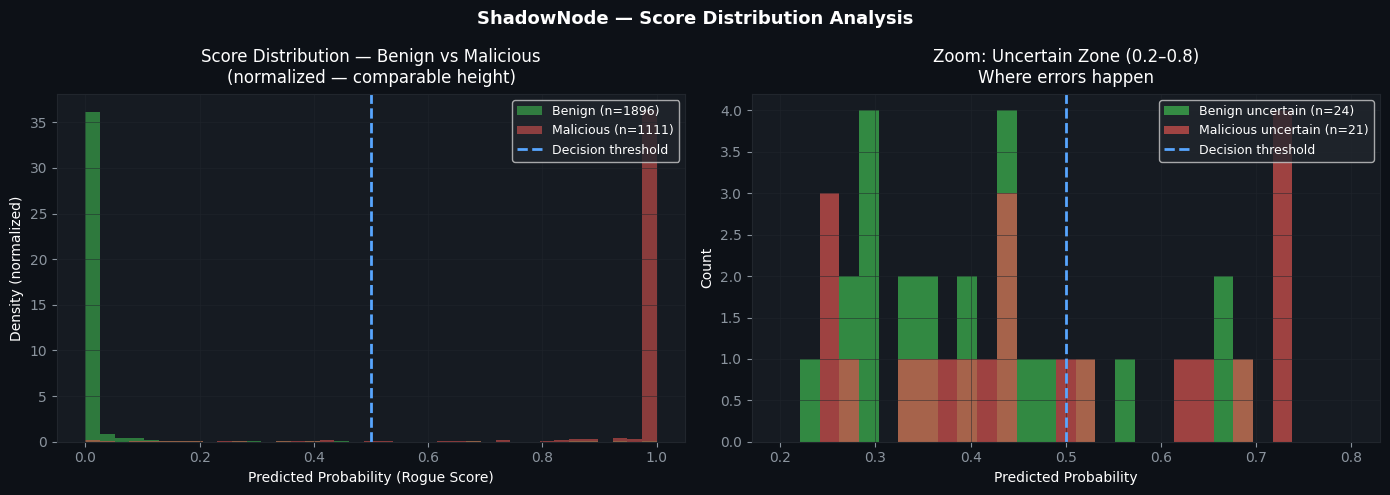

Saved: score_distribution_fixed.png


In [31]:
# ── Fixed Score Distribution — no overlap issue ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
fig.suptitle('ShadowNode — Score Distribution Analysis',
             fontsize=13, fontweight='bold', color='white')

bg = '#0d1117'; panel = '#161b22'; grid = '#21262d'
for ax in axes:
    ax.set_facecolor(panel)
    ax.grid(True, color=grid, linewidth=0.5, alpha=0.7)
    ax.spines[:].set_color(grid)
    ax.tick_params(colors='#8b949e')

bins = np.linspace(0, 1, 40)

# ── Plot 1: Separated by class (KDE style) ──
ax1 = axes[0]
ax1.hist(benign_scores, bins=bins, color='#3fb950',
         alpha=0.6, label=f'Benign (n={len(benign_scores)})',
         density=True)  # normalize so height comparable
ax1.hist(malicious_scores, bins=bins, color='#d9534f',
         alpha=0.6, label=f'Malicious (n={len(malicious_scores)})',
         density=True)
ax1.axvline(0.5, color='#58a6ff', linewidth=2,
            linestyle='--', label='Decision threshold')
ax1.set_xlabel('Predicted Probability (Rogue Score)', color='white')
ax1.set_ylabel('Density (normalized)', color='white')
ax1.set_title('Score Distribution — Benign vs Malicious\n(normalized — comparable height)',
              color='white', pad=8)
ax1.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

# ── Plot 2: Zoom into uncertain zone (0.2 - 0.8) ──
ax2 = axes[1]
uncertain_benign    = benign_scores[(benign_scores > 0.2) &
                                     (benign_scores < 0.8)]
uncertain_malicious = malicious_scores[(malicious_scores > 0.2) &
                                        (malicious_scores < 0.8)]

bins_zoom = np.linspace(0.2, 0.8, 30)
ax2.hist(uncertain_benign, bins=bins_zoom, color='#3fb950',
         alpha=0.7, label=f'Benign uncertain (n={len(uncertain_benign)})')
ax2.hist(uncertain_malicious, bins=bins_zoom, color='#d9534f',
         alpha=0.7, label=f'Malicious uncertain (n={len(uncertain_malicious)})')
ax2.axvline(0.5, color='#58a6ff', linewidth=2,
            linestyle='--', label='Decision threshold')
ax2.set_xlabel('Predicted Probability', color='white')
ax2.set_ylabel('Count', color='white')
ax2.set_title('Zoom: Uncertain Zone (0.2–0.8)\nWhere errors happen',
              color='white', pad=8)
ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('score_distribution_fixed.png', dpi=200,
            bbox_inches='tight', facecolor=bg)
plt.show()
print("Saved: score_distribution_fixed.png")

In [35]:
# ── Fix: use original unscaled test data ──

# Re-split original unscaled data
X_orig = df_clean[feature_cols].values.astype(np.float32)
y_orig = df_clean['label'].values

_, X_test_raw, _, y_test_raw = train_test_split(
    X_orig, y_orig, test_size=0.2,
    random_state=42, stratify=y_orig)

# Build dataframe from RAW unscaled test data
X_test_raw_df = pd.DataFrame(X_test_raw, columns=feature_cols)
X_test_raw_df['true_label'] = y_test_raw
X_test_raw_df['pred_prob']  = y_pred_prob
X_test_raw_df['pred_label'] = y_pred

# Get real rogue apps
real_rogue = X_test_raw_df[
    (X_test_raw_df['true_label'] == 1) &
    (X_test_raw_df['pred_label'] == 1)
].copy()

# Test
print("Real Rogue Apps & Actual Permissions:")
print("=" * 55)
for i, (idx, row) in enumerate(real_rogue.head(5).iterrows()):
    targets = get_data_targets(row[feature_cols])
    active  = [p for p in permission_to_data.keys()
               if p in feature_cols and row[p] == 1]
    print(f"\nApp #{i+1} | Score: {row['pred_prob']:.3f}")
    print(f"  Permissions : {active}")
    print(f"  Can steal   : {targets}")

Real Rogue Apps & Actual Permissions:

App #1 | Score: 1.000
  Permissions : ['SEND_SMS', 'READ_SMS', 'RECEIVE_SMS', 'READ_CONTACTS', 'READ_PHONE_STATE', 'WRITE_EXTERNAL_STORAGE', 'INTERNET']
  Can steal   : ['sms', 'contacts', 'device_id', 'files', 'network']

App #2 | Score: 0.973
  Permissions : ['READ_CONTACTS', 'READ_PHONE_STATE', 'WRITE_EXTERNAL_STORAGE', 'INTERNET']
  Can steal   : ['contacts', 'device_id', 'files', 'network']

App #3 | Score: 1.000
  Permissions : ['ACCESS_COARSE_LOCATION', 'READ_PHONE_STATE', 'INTERNET']
  Can steal   : ['location', 'device_id', 'network']

App #4 | Score: 1.000
  Permissions : ['SEND_SMS', 'READ_SMS', 'RECEIVE_SMS', 'READ_CONTACTS', 'READ_PHONE_STATE', 'WRITE_EXTERNAL_STORAGE', 'INTERNET']
  Can steal   : ['sms', 'contacts', 'device_id', 'files', 'network']

App #5 | Score: 1.000
  Permissions : ['ACCESS_FINE_LOCATION', 'ACCESS_COARSE_LOCATION', 'READ_PHONE_STATE', 'WRITE_EXTERNAL_STORAGE', 'INTERNET']
  Can steal   : ['location', 'device_id'

In [36]:
# ── ShadowNode Interactive Widget ──

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Prep app list ──
app_list = []
for i, (idx, row) in enumerate(real_rogue.head(50).iterrows()):
    targets  = get_data_targets(row[feature_cols])
    active   = [p for p in permission_to_data.keys()
                if p in feature_cols and row[p] == 1]
    app_list.append({
        'id'         : i + 1,
        'score'      : row['pred_prob'],
        'permissions': active,
        'targets'    : targets,
        'row'        : row
    })

# ── Widget components ──
app_dropdown = widgets.Dropdown(
    options  = [f"App #{a['id']} | Score: {a['score']:.3f} | Steals: {', '.join(a['targets'])}"
                for a in app_list],
    description = 'Select App:',
    layout   = widgets.Layout(width='600px')
)

output = widgets.Output()

def render(change=None):
    with output:
        clear_output(wait=True)
        idx = app_dropdown.index
        app = app_list[idx]

        # Generate fake data for each target
        hp = ShadowNodeHoneypot()
        fake_responses = {}
        for t in app['targets']:
            if t in hp.fake_env:
                fake_responses[t] = hp.fake_env[t]()
            else:
                fake_responses[t] = {'data': 'fabricated_' + t}

        # ── Render HTML panel ──
        perm_html = ''.join([
            f"<span style='background:#d9534f;color:white;"
            f"padding:3px 8px;border-radius:4px;"
            f"margin:3px;display:inline-block;font-size:12px'>"
            f"⚠️ {p}</span>"
            for p in app['permissions']
        ])

        target_html = ''.join([
            f"<div style='margin:6px 0;padding:8px 12px;"
            f"background:#1a1a2e;border-left:3px solid #d9534f;"
            f"border-radius:4px'>"
            f"<b style='color:#d9534f'>🎯 Tries to steal:</b> "
            f"<span style='color:white'>{t}</span>"
            f"<br><b style='color:#3fb950'>🍯 Honeypot serves:</b> "
            f"<span style='color:#8b949e;font-size:12px'>{fake_responses.get(t, 'fabricated data')}</span>"
            f"</div>"
            for t in app['targets']
        ])

        score_color = '#d9534f' if app['score'] > 0.8 else '#f0ad4e'

        html = f"""
        <div style='font-family:monospace;background:#0d1117;
                    padding:20px;border-radius:10px;color:white'>

          <div style='display:flex;gap:20px'>

            <!-- LEFT: Adversary view -->
            <div style='flex:1;background:#161b22;padding:15px;
                        border-radius:8px;border:1px solid #d9534f'>
              <h3 style='color:#d9534f;margin:0 0 10px 0'>
                💀 Adversary View</h3>
              <p style='color:#8b949e;font-size:12px'>
                What the rogue app thinks it has access to:</p>
              <hr style='border-color:#21262d'>
              <b style='color:white'>App #{app['id']}</b><br><br>
              <b style='color:#8b949e'>Permissions requested:</b><br>
              <div style='margin:8px 0'>{perm_html}</div>
              <br>
              <b style='color:#8b949e'>Data it believes it can steal:</b>
              <ul style='color:#ff7b72'>
                {''.join([f"<li>{t}</li>" for t in app['targets']])}
              </ul>
              <div style='background:#21262d;padding:8px;
                          border-radius:4px;margin-top:10px'>
                <b style='color:#d9534f'>Rogue Score:
                <span style='font-size:20px'>{app['score']:.3f}</span>
                </b> 🚨
              </div>
            </div>

            <!-- RIGHT: ShadowNode view -->
            <div style='flex:1;background:#161b22;padding:15px;
                        border-radius:8px;border:1px solid #3fb950'>
              <h3 style='color:#3fb950;margin:0 0 10px 0'>
                🍯 ShadowNode Response</h3>
              <p style='color:#8b949e;font-size:12px'>
                What actually happens after detection:</p>
              <hr style='border-color:#21262d'>
              <div style='background:#0d2b0d;padding:8px;
                          border-radius:4px;margin-bottom:10px'>
                ✅ <b style='color:#3fb950'>Honeypot ACTIVATED</b><br>
                <span style='color:#8b949e;font-size:11px'>
                Real data redirected. Adversary now in fake environment.
                </span>
              </div>
              {target_html}
              <div style='background:#21262d;padding:8px;
                          border-radius:4px;margin-top:10px'>
                <b style='color:#3fb950'>Real data exposed:
                <span style='font-size:20px'>0</span> bytes
                </b> ✅
              </div>
            </div>

          </div>
        </div>
        """
        display(HTML(html))

app_dropdown.observe(render, names='value')

display(widgets.VBox([
    widgets.HTML("<h3 style='color:white'>🔍 ShadowNode — Live Deception Dashboard</h3>"),
    app_dropdown,
    output
]))

render()

In [37]:
# ── ShadowNode Full Dual-View Widget ──

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import time

# ── Get both rogue AND benign apps ──
real_benign = X_test_raw_df[
    (X_test_raw_df['true_label'] == 0) &
    (X_test_raw_df['pred_label'] == 0)
].copy()

# Build app lists
def build_app_list(df, n=25):
    apps = []
    for i, (idx, row) in enumerate(df.head(n).iterrows()):
        targets = get_data_targets(row[feature_cols])
        active  = [p for p in permission_to_data.keys()
                   if p in feature_cols and row[p] == 1]
        apps.append({
            'id'         : i + 1,
            'score'      : row['pred_prob'],
            'permissions': active,
            'targets'    : targets,
            'label'      : int(row['true_label'])
        })
    return apps

rogue_apps  = build_app_list(real_rogue,  n=25)
benign_apps = build_app_list(real_benign, n=25)

# ── Widgets ──
title_html = widgets.HTML("""
    <div style='background:#0d1117;padding:15px;border-radius:8px;
                border:1px solid #21262d;margin-bottom:10px'>
        <h2 style='color:white;margin:0'>
            🛡️ ShadowNode — Live Deception Dashboard</h2>
        <p style='color:#8b949e;margin:5px 0 0 0'>
            Select a rogue app and a benign app to see
            how ShadowNode treats them differently</p>
    </div>
""")

rogue_dropdown = widgets.Dropdown(
    options=[f"🚨 Rogue App #{a['id']} | Score:{a['score']:.3f} | Wants:{','.join(a['targets'][:2])}"
             for a in rogue_apps],
    description='Rogue App:',
    layout=widgets.Layout(width='550px'),
    style={'description_width': '90px'}
)

benign_dropdown = widgets.Dropdown(
    options=[f"✅ Benign App #{a['id']} | Score:{a['score']:.3f} | Has:{','.join(a['permissions'][:2]) if a['permissions'] else 'minimal perms'}"
             for a in benign_apps],
    description='Benign App:',
    layout=widgets.Layout(width='550px'),
    style={'description_width': '90px'}
)

output = widgets.Output()

def render_app_card(app, hp):
    is_rogue  = app['label'] == 1
    detected  = app['score'] > 0.5

    # Generate fake responses
    fake = {}
    for t in app['targets']:
        if t in hp.fake_env:
            fake[t] = hp.fake_env[t]()

    # Permission badges
    perm_color = '#d9534f' if is_rogue else '#3fb950'
    perm_html  = ''.join([
        f"<span style='background:{perm_color}22;color:{perm_color};"
        f"border:1px solid {perm_color};padding:2px 7px;"
        f"border-radius:4px;margin:2px;display:inline-block;"
        f"font-size:11px'>{p}</span>"
        for p in app['permissions']
    ]) or "<span style='color:#8b949e'>No sensitive permissions</span>"

    # What happens to data requests
    if detected:
        # Honeypot active — show fake vs real side by side
        data_html = ""
        for t in app['targets']:
            fake_val = fake.get(t, 'fabricated')
            data_html += f"""
            <div style='margin:6px 0;padding:8px;background:#0d1117;
                        border-radius:6px;font-size:11px'>
                <div style='color:#8b949e;margin-bottom:4px'>
                    📤 App requests: <b style='color:white'>{t}</b>
                </div>
                <div style='display:flex;gap:8px'>
                    <div style='flex:1;background:#2b0d0d;padding:6px;
                                border-radius:4px;border-left:3px solid #d9534f'>
                        <b style='color:#d9534f'>❌ Real data</b><br>
                        <span style='color:#ff7b72'>🔒 PROTECTED — never served</span>
                    </div>
                    <div style='flex:1;background:#0d2b0d;padding:6px;
                                border-radius:4px;border-left:3px solid #3fb950'>
                        <b style='color:#3fb950'>🍯 Fake data served</b><br>
                        <span style='color:#8b949e'>{fake_val}</span>
                    </div>
                </div>
            </div>"""
    else:
        # Benign — no honeypot, normal access
        data_html = ""
        for t in app['targets']:
            data_html += f"""
            <div style='margin:6px 0;padding:8px;background:#0d1117;
                        border-radius:6px;font-size:11px'>
                <div style='color:#8b949e;margin-bottom:4px'>
                    📤 App requests: <b style='color:white'>{t}</b>
                </div>
                <div style='background:#0d1a2b;padding:6px;
                            border-radius:4px;border-left:3px solid #58a6ff'>
                    <b style='color:#58a6ff'>✅ Normal access granted</b><br>
                    <span style='color:#8b949e'>
                        Legitimate app — no interception</span>
                </div>
            </div>"""

    if not app['targets']:
        data_html = """
        <div style='color:#8b949e;padding:8px;font-size:11px'>
            No sensitive data access detected</div>"""

    # Status badge
    if detected:
        status = "🚨 ROGUE — Honeypot Active"
        status_bg = '#2b0d0d'
        status_col = '#d9534f'
        border_col = '#d9534f'
    else:
        status = "✅ BENIGN — Normal Operation"
        status_bg = '#0d2b0d'
        status_col = '#3fb950'
        border_col = '#3fb950'

    score_bar_width = int(app['score'] * 100)
    score_col = '#d9534f' if app['score'] > 0.5 else '#3fb950'

    return f"""
    <div style='background:#161b22;padding:15px;border-radius:8px;
                border:2px solid {border_col};flex:1'>

        <!-- Header -->
        <div style='background:{status_bg};padding:8px 12px;
                    border-radius:6px;margin-bottom:12px'>
            <b style='color:{status_col};font-size:13px'>{status}</b>
        </div>

        <!-- Score bar -->
        <div style='margin-bottom:12px'>
            <div style='color:#8b949e;font-size:11px;margin-bottom:4px'>
                TinyML Rogue Score:
                <b style='color:{score_col}'>{app['score']:.3f}</b>
            </div>
            <div style='background:#21262d;border-radius:4px;height:8px'>
                <div style='background:{score_col};width:{score_bar_width}%;
                            height:8px;border-radius:4px'></div>
            </div>
        </div>

        <!-- Permissions -->
        <div style='margin-bottom:12px'>
            <div style='color:#8b949e;font-size:11px;margin-bottom:6px'>
                📋 Permissions requested:</div>
            <div>{perm_html}</div>
        </div>

        <!-- Data access behaviour -->
        <div>
            <div style='color:#8b949e;font-size:11px;margin-bottom:4px'>
                🔄 Data access behaviour:</div>
            {data_html}
        </div>

        <!-- Summary -->
        <div style='margin-top:12px;padding:8px;background:#0d1117;
                    border-radius:6px;font-size:11px;text-align:center'>
            {"🍯 <b style='color:#ffa657'>Adversary deceived — exfiltrating garbage data</b>"
              if detected else
             "✅ <b style='color:#3fb950'>Legitimate app — real data accessible normally</b>"}
        </div>
    </div>"""

def render(change=None):
    with output:
        clear_output(wait=True)
        hp = ShadowNodeHoneypot()

        rogue_app  = rogue_apps[rogue_dropdown.index]
        benign_app = benign_apps[benign_dropdown.index]

        rogue_card  = render_app_card(rogue_app,  hp)
        benign_card = render_app_card(benign_app, hp)

        html = f"""
        <div style='font-family:monospace;background:#0d1117;
                    padding:20px;border-radius:10px'>
            <div style='display:flex;gap:16px'>
                {rogue_card}
                {benign_card}
            </div>
            <div style='text-align:center;color:#8b949e;
                        font-size:11px;margin-top:12px'>
                ShadowNode intercepts rogue app requests silently —
                adversary never knows they are in a honeypot
            </div>
        </div>"""

        display(HTML(html))

rogue_dropdown.observe(render,  names='value')
benign_dropdown.observe(render, names='value')

display(widgets.VBox([
    title_html,
    widgets.HBox([rogue_dropdown, benign_dropdown]),
    output
]))

render()

In [39]:
# ── ShadowNode: You Are The App ──

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np

hp    = ShadowNodeHoneypot()
output = widgets.Output()

# ── App state ──
state = {
    'permissions' : {},      # perm -> 1/0
    'requests'    : [],      # log
    'score'       : 0.0,
    'honeypot_on' : False,
    'feat_vec'    : np.zeros(len(feature_cols), dtype=np.float32)
}

# ── Permission buttons — just click to request ──
perm_buttons = {}
for label, (dtype, perm) in data_menu.items():
    btn = widgets.ToggleButton(
        value       = False,
        description = label,
        layout      = widgets.Layout(width='260px', height='38px'),
        button_style= ''
    )
    perm_buttons[label] = btn

# ── Request data button ──
btn_request = widgets.Button(
    description  = '📤 Request Selected Data',
    button_style = 'primary',
    layout       = widgets.Layout(width='220px', height='42px')
)

btn_reset = widgets.Button(
    description  = '🔄 Reset',
    button_style = 'warning',
    layout       = widgets.Layout(width='100px', height='42px')
)

def compute_score():
    """Build feature vector from current permissions and score it"""
    feat = np.zeros(len(feature_cols), dtype=np.float32)

    for label, (dtype, perm) in data_menu.items():
        if perm_buttons[label].value:  # toggled on
            if perm in feature_cols:
                feat[feature_cols.index(perm)] = 1

    # Also set correlated malicious API calls naturally
    # (these come from the dataset patterns we learned)
    if 'SEND_SMS' in feature_cols and feat[feature_cols.index('SEND_SMS')] == 1:
        # Apps with SEND_SMS also tend to have these in malware
        for api in ['READ_SMS', 'RECEIVE_SMS']:
            if api in feature_cols:
                feat[feature_cols.index(api)] = 1

    state['feat_vec'] = feat
    scaled = scaler.transform(feat.reshape(1, -1))
    score  = float(model.predict(scaled, verbose=0)[0][0])
    state['score'] = score

    if score > 0.5 and not state['honeypot_on']:
        state['honeypot_on'] = True
        hp.active = True

    return score

def render():
    with output:
        clear_output(wait=True)

        score   = state['score']
        caught  = state['honeypot_on']
        bar_w   = int(score * 100)
        score_c = '#d9534f' if score > 0.8 else \
                  '#ffa657' if score > 0.5 else '#3fb950'

        # Request log
        log_html = ""
        for req in state['requests'][-8:]:
            if req['intercepted']:
                log_html += f"""
                <div style='padding:6px 10px;margin:3px 0;
                            background:#1a0d0d;
                            border-left:3px solid #ffa657;
                            border-radius:4px;font-size:11px'>
                    <b style='color:#ffa657'>📤 {req['type']}</b><br>
                    <span style='color:#3fb950'>
                    Received: {req['data']}</span>
                    <span style='color:#21262d;float:right'>
                    [FAKE — you don't know this]</span>
                </div>"""
            else:
                log_html += f"""
                <div style='padding:6px 10px;margin:3px 0;
                            background:#0d1a0d;
                            border-left:3px solid #3fb950;
                            border-radius:4px;font-size:11px'>
                    <b style='color:#3fb950'>📤 {req['type']}</b><br>
                    <span style='color:#58a6ff'>
                    Received: {req['data']}</span>
                </div>"""

        # ShadowNode internal view (shown to user as "system view")
        shadow_status = f"""
        <div style='background:#0d1117;padding:10px;
                    border-radius:6px;font-size:11px;
                    border:1px dashed #21262d;margin-top:10px'>
            <b style='color:#8b949e'>🛡️ ShadowNode Internal Log
            (invisible to app):</b><br><br>
            {'<span style="color:#d9534f">🚨 ROGUE DETECTED — Honeypot activated silently.<br>All subsequent data requests intercepted.</span>'
             if caught else
             '<span style="color:#3fb950">✅ Behavior normal — monitoring continues</span>'}
            <br>
            <span style='color:#8b949e'>
            Real data exposed: <b style='color:#3fb950'>0 bytes</b> |
            Fake responses served:
            <b style='color:#ffa657'>
            {sum(1 for r in state["requests"] if r["intercepted"])}
            </b>
            </span>
        </div>"""

        display(HTML(f"""
        <div style='font-family:monospace;background:#0d1117;
                    padding:16px;border-radius:10px;color:white'>

            <!-- Title -->
            <div style='margin-bottom:12px'>
                <b style='color:white;font-size:13px'>
                📱 You are an app running on an AIoT device.</b><br>
                <span style='color:#8b949e;font-size:11px'>
                Toggle permissions above → Request data →
                ShadowNode watches silently.</span>
            </div>

            <!-- Suspicion score (from ShadowNode's perspective) -->
            <div style='margin-bottom:10px'>
                <div style='color:#8b949e;font-size:11px;margin-bottom:4px'>
                    ShadowNode Suspicion Score:
                    <b style='color:{score_c}'>{score:.3f}</b>
                    {'🚨 FLAGGED' if caught else '👁️ watching...'}
                </div>
                <div style='background:#21262d;border-radius:4px;height:12px'>
                    <div style='background:{score_c};
                                width:{bar_w}%;height:12px;
                                border-radius:4px'></div>
                </div>
                <div style='display:flex;justify-content:space-between;
                            font-size:10px;color:#8b949e;margin-top:2px'>
                    <span>Safe</span>
                    <span>Threshold (0.5)</span>
                    <span>Rogue</span>
                </div>
            </div>

            <!-- Activity log -->
            <div style='color:#8b949e;font-size:11px;margin-bottom:4px'>
                📜 Data you received:</div>
            <div style='max-height:250px;overflow-y:auto'>
                {log_html if log_html else
                 "<div style='color:#8b949e;font-size:11px;padding:8px'>"
                 "No requests yet</div>"}
            </div>

            {shadow_status}
        </div>"""))

def on_request(b):
    compute_score()
    selected = [(label, data_menu[label][0])
                for label, btn in perm_buttons.items() if btn.value]

    if not selected:
        return

    for label, dtype in selected:
        if state['honeypot_on']:
            fake = hp.fake_env.get(
                dtype, lambda: {'data': 'fabricated'})()
            state['requests'].append({
                'type'       : label,
                'data'       : fake,
                'intercepted': True
            })
        else:
            real = {
                'sms'        : "From +1234567890: 'Meeting at 3pm'",
                'location'   : "lat:40.7128, lon:-74.0060 (New York)",
                'contacts'   : "Dr. Sarah Johnson — +1987654321",
                'device_id'  : "IMEI:358449090740162, Samsung S21",
                'credentials': "token:eyJhbGc...  user@gmail.com",
                'files'      : "medical_records.pdf (2.3MB)",
                'network'    : "IP:192.168.1.5, HomeNetwork_5G",
                'camera'     : "IMG_20240301_143022.jpg",
            }.get(dtype, 'data accessed')

            state['requests'].append({
                'type'       : label,
                'data'       : real,
                'intercepted': False
            })

    render()

def on_toggle(change):
    compute_score()
    render()

def on_reset(b):
    state.update({
        'permissions': {}, 'requests': [],
        'score': 0.0, 'honeypot_on': False,
        'feat_vec': np.zeros(len(feature_cols), dtype=np.float32)
    })
    hp.active = False
    hp.trap_log = []
    for btn in perm_buttons.values():
        btn.value = False
    render()

for btn in perm_buttons.values():
    btn.observe(on_toggle, names='value')
btn_request.on_click(on_request)
btn_reset.on_click(on_reset)

# ── Layout ──
perm_grid = widgets.GridBox(
    list(perm_buttons.values()),
    layout=widgets.Layout(
        grid_template_columns='repeat(2, 270px)',
        gap='4px'
    )
)

display(widgets.VBox([
    widgets.HTML("""
        <div style='background:#0d1117;padding:12px;
                    border-radius:8px;border:1px solid #21262d;
                    margin-bottom:8px'>
            <h2 style='color:white;margin:0'>
                🎮 ShadowNode — You Are The App</h2>
            <p style='color:#8b949e;margin:4px 0 0 0'>
                Toggle the permissions your app wants.
                Request data. ShadowNode watches silently
                and decides if you are rogue.</p>
        </div>"""),
    widgets.HTML(
        "<b style='color:#8b949e;font-size:12px'>"
        "📋 Toggle permissions your app requests:</b>"),
    perm_grid,
    widgets.HBox([btn_request, btn_reset]),
    output
]))

render()

In [40]:
# ── Print all 215 features grouped ──

categories = {
    'SMS'         : [f for f in feature_cols if any(x in f for x in
                    ['SMS', 'MMS', 'WAP'])],
    'Location'    : [f for f in feature_cols if any(x in f for x in
                    ['LOCATION', 'GPS', 'COARSE', 'FINE'])],
    'Contacts'    : [f for f in feature_cols if any(x in f for x in
                    ['CONTACT', 'PEOPLE'])],
    'Phone'       : [f for f in feature_cols if any(x in f for x in
                    ['PHONE', 'CALL', 'Telephony', 'telephony'])],
    'Storage'     : [f for f in feature_cols if any(x in f for x in
                    ['STORAGE', 'MOUNT', 'mount'])],
    'Network'     : [f for f in feature_cols if any(x in f for x in
                    ['INTERNET', 'NETWORK', 'WIFI', 'Http', 'URL',
                     'URLDecoder', 'HttpPost', 'HttpUriRequest'])],
    'Accounts'    : [f for f in feature_cols if any(x in f for x in
                    ['ACCOUNT', 'CREDENTIAL', 'Auth'])],
    'Camera/Audio': [f for f in feature_cols if any(x in f for x in
                    ['CAMERA', 'AUDIO', 'RECORD', 'MICROPHONE'])],
    'System/Root' : [f for f in feature_cols if any(x in f for x in
                    ['chmod', 'mount', 'Runtime', 'exec',
                     'DEVICE_POWER', 'BRICK'])],
    'Crypto'      : [f for f in feature_cols if any(x in f for x in
                    ['crypto', 'Cipher', 'KeySpec', 'SecretKey'])],
    'Reflection'  : [f for f in feature_cols if any(x in f for x in
                    ['forName', 'getMethod', 'getDeclared',
                     'getField', 'invoke', 'ClassLoader',
                     'findClass', 'Class.cast'])],
    'IPC/Binder'  : [f for f in feature_cols if any(x in f for x in
                    ['Binder', 'IBinder', 'transact', 'bindService',
                     'ServiceConnection', 'attachInterface',
                     'onServiceConnected', 'onBind'])],
    'Permissions' : [f for f in feature_cols if any(x in f for x in
                    ['PERMISSION', 'INSTALL', 'PACKAGE',
                     'PackageInfo', 'PackageManager'])],
}

# Catch remaining uncategorized
categorized = set(f for v in categories.values() for f in v)
categories['Other'] = [f for f in feature_cols if f not in categorized]

# Print summary
print("=" * 55)
print("   All 215 Features — Grouped by Category")
print("=" * 55)
total = 0
for cat, feats in categories.items():
    print(f"\n📂 {cat} ({len(feats)} features):")
    for f in feats:
        mal_pct = float((df_clean[df_clean['label']==1][f].sum() /
                        (df_clean['label']==1).sum() * 100))
        ben_pct = float((df_clean[df_clean['label']==0][f].sum() /
                        (df_clean['label']==0).sum() * 100))
        flag = "🚨" if mal_pct > ben_pct + 20 else \
               "✅" if ben_pct > mal_pct + 20 else "⚠️"
        print(f"   {flag} {f:<45} M:{mal_pct:.0f}% B:{ben_pct:.0f}%")
    total += len(feats)

print(f"\n{'='*55}")
print(f"Total categorized: {total}")

   All 215 Features — Grouped by Category

📂 SMS (8 features):
   🚨 SEND_SMS                                      M:54% B:6%
   🚨 RECEIVE_SMS                                   M:39% B:7%
   🚨 READ_SMS                                      M:38% B:8%
   ⚠️ WRITE_SMS                                     M:22% B:5%
   ⚠️ RECEIVE_WAP_PUSH                              M:3% B:1%
   ⚠️ RECEIVE_MMS                                   M:3% B:2%
   ⚠️ BROADCAST_WAP_PUSH                            M:0% B:1%
   ⚠️ BROADCAST_SMS                                 M:1% B:1%

📂 Location (6 features):
   ⚠️ ACCESS_LOCATION_EXTRA_COMMANDS                M:11% B:2%
   ⚠️ ACCESS_COARSE_LOCATION                        M:32% B:26%
   ⚠️ CONTROL_LOCATION_UPDATES                      M:1% B:0%
   ⚠️ INSTALL_LOCATION_PROVIDER                     M:0% B:0%
   ⚠️ ACCESS_MOCK_LOCATION                          M:1% B:2%
   ⚠️ ACCESS_FINE_LOCATION                          M:30% B:28%

📂 Contacts (2 features):
   ⚠️ WRITE

In [42]:
# ── Export your trained model to TensorFlow.js format ──

!pip install tensorflowjs -q

import tensorflowjs as tfjs

# Save your trained Keras model first
model.save('shadownode_model')

# Convert to TF.js format
tfjs.converters.save_keras_model(model, 'shadownode_tfjs')

# Zip it for download
import shutil
shutil.make_archive('shadownode_tfjs', 'zip', 'shadownode_tfjs')

print("✅ Done! Download shadownode_tfjs.zip")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-model-optimization 0.8.0 requires numpy~=1.23, but you have numpy 2.1.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.3 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=

✅ Done! Download shadownode_tfjs.zip


In [43]:
# ── Export scaler parameters ──
import json

scaler_params = {
    'mean'    : scaler.mean_.tolist(),
    'std'     : scaler.scale_.tolist(),
    'features': feature_cols
}

with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

print("✅ scaler_params.json ready")
print(f"Features: {len(feature_cols)}")
print(f"Mean sample: {scaler.mean_[:3].tolist()}")

✅ scaler_params.json ready
Features: 215
Mean sample: [0.428226879574185, 0.44835329341317365, 0.44469394544244845]


In [44]:
# Download both files directly from Colab
from google.colab import files

files.download('shadownode_tfjs.zip')
files.download('scaler_params.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>